In [1]:
!git clone https://github.com/khaliddosari/Deep-Learning-Project-Tuwaiq.git

Cloning into 'Deep-Learning-Project-Tuwaiq'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 36 (delta 6), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 626.99 KiB | 2.08 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
%cd Deep-Learning-Project-Tuwaiq

/content/Deep-Learning-Project-Tuwaiq


In [3]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        if (base / "src" / "config.py").is_file():
            return base

    for child in sorted(c for c in start.iterdir() if c.is_dir()):
        if (child / "src" / "config.py").is_file():
            return child

    raise RuntimeError(f"Could not find the project root from {start}.")

ROOT = find_project_root(Path.cwd())

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)

Project root: /content/Deep-Learning-Project-Tuwaiq


In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)

Project root: /content/Deep-Learning-Project-Tuwaiq


In [6]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from src.config import IMG_SHAPE, NUM_CLASSES, SEED
from src.data import load_splits
from src.models import build_dense_model, validate_model
from src.utils import set_seed

set_seed(SEED)

data = load_splits()

print(data.summary())

No dataset found at /content/Deep-Learning-Project-Tuwaiq/Dataset/cifar-10-batches-py
-- expect ~25 minutes. Let it run; do NOT interrupt the kernel, because
Keras cannot resume a partial download.

To skip the download entirely:
Ask your teammate for 'cifar-10-batches-py.zip' and unzip it so the
batch files sit directly in this folder, with no extra nesting:
  /content/Deep-Learning-Project-Tuwaiq/Dataset/cifar-10-batches-py
    data_batch_1, data_batch_2, data_batch_3, data_batch_4, data_batch_5, test_batch

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1750s 10us/step
X_train  (45000, 32, 32, 3)  float32
X_val    (5000, 32, 32, 3)   float32
X_test   (10000, 32, 32, 3)  float32
y_train  (45000,)            int32
y_val    (5000,)             int32
y_test   (10000,)            int32


In [8]:
HIDDEN_UNITS = [128, 128, 128]

LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 50

print("Selected architecture:", HIDDEN_UNITS)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Selected architecture: [128, 128, 128]
Learning rate: 0.001
Batch size: 32
Epochs: 50


In [9]:
baseline_model = build_dense_model(
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
    optimizer="adam",
    seed=SEED,
    name="medium_baseline"
)

baseline_model.summary()

Model: "medium_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427,658 (1.63 MB)

 Trainable params: 427,658 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
set_seed(SEED)

baseline_model = build_dense_model(
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    name="medium_baseline"
)

baseline_history = baseline_model.fit(
    data.X_train,
    data.y_train,
    validation_data=(data.X_val, data.y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3205 - loss: 1.8625 - val_accuracy: 0.3856 - val_loss: 1.7311
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3878 - loss: 1.6983 - val_accuracy: 0.4036 - val_loss: 1.6709
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4136 - loss: 1.6241 - val_accuracy: 0.4270 - val_loss: 1.6082
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4345 - loss: 1.5730 - val_accuracy: 0.4316 - val_loss: 1.6120
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4465 - loss: 1.5370 - val_accuracy: 0.4326 - val_loss: 1.6083
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4568 - loss: 1.5072 - val_accuracy: 0.4364 - val_loss: 1.5959
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4655 - loss: 1.4817 - val_accuracy: 0.4382 - val_loss: 1.5984
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4739 - loss: 1.4587 - 

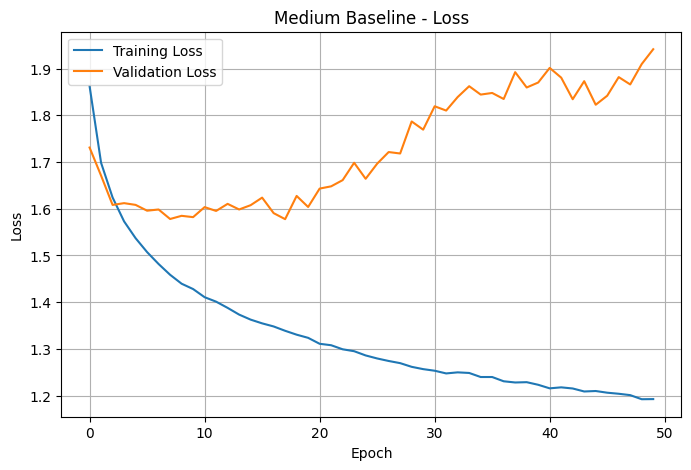

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Medium Baseline - Loss")
plt.legend()
plt.grid(True)
plt.show()

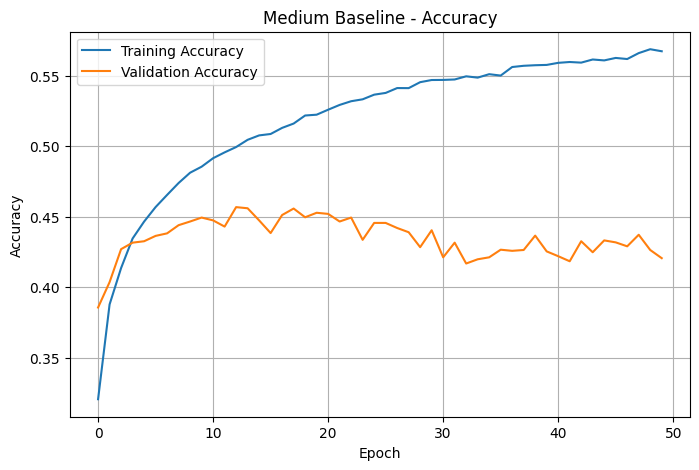

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Medium Baseline - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
best_val_acc = max(baseline_history.history["val_accuracy"])
best_val_acc_epoch = (
    baseline_history.history["val_accuracy"].index(best_val_acc) + 1
)

min_val_loss = min(baseline_history.history["val_loss"])
min_val_loss_epoch = (
    baseline_history.history["val_loss"].index(min_val_loss) + 1
)

final_train_acc = baseline_history.history["accuracy"][-1]
final_val_acc = baseline_history.history["val_accuracy"][-1]

final_train_loss = baseline_history.history["loss"][-1]
final_val_loss = baseline_history.history["val_loss"][-1]

print("===== MEDIUM BASELINE =====")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")
print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
print(f"Final Training Accuracy  : {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss      : {final_train_loss:.4f}")
print(f"Final Validation Loss    : {final_val_loss:.4f}")

===== MEDIUM BASELINE =====
Best Validation Accuracy : 0.4568
Best Validation Acc Epoch: 13
Minimum Validation Loss  : 1.5777
Minimum Val Loss Epoch   : 18
Final Training Accuracy  : 0.5674
Final Validation Accuracy: 0.4206
Final Training Loss      : 1.1925
Final Validation Loss    : 1.9416


### PART9-17

# Part 9 - Learning Rate Experiment

We test different learning rates while keeping the selected Medium architecture
[128, 128, 128] and all other hyperparameters unchanged.

In [15]:
# Load the same train/validation/test split used throughout the project

splits = load_splits()

X_train = splits.X_train
y_train = splits.y_train

X_val = splits.X_val
y_val = splits.y_val

X_test = splits.X_test
y_test = splits.y_test

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
X_val: (5000, 32, 32, 3)
X_test: (10000, 32, 32, 3)
y_train: (45000,)
y_val: (5000,)
y_test: (10000,)


In [16]:
# Part 9 - Learning Rate Experiment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt

# Fixed settings from the selected Medium architecture
HIDDEN_UNITS = [128, 128, 128]
BATCH_SIZE = 32
EPOCHS = 50

LEARNING_RATES = [0.01, 0.001, 0.0001]

print("Architecture:", HIDDEN_UNITS)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rates:", LEARNING_RATES)

Architecture: [128, 128, 128]
Batch size: 32
Epochs: 50
Learning rates: [0.01, 0.001, 0.0001]


In [17]:
def build_medium_model(learning_rate):

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [18]:
learning_rate_results = {}
learning_rate_histories = {}

for lr in LEARNING_RATES:

    print("\n" + "=" * 60)
    print(f"Training with Learning Rate = {lr}")
    print("=" * 60)

    # Fresh model = fresh weights
    model = build_medium_model(lr)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    learning_rate_histories[lr] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    learning_rate_results[lr] = {
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": final_train_acc,
        "Final Val Accuracy": final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Val Loss": final_val_loss
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
    print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Training with Learning Rate = 0.01


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2281 - loss: 2.0684 - val_accuracy: 0.2282 - val_loss: 1.9958
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2576 - loss: 1.9602 - val_accuracy: 0.2690 - val_loss: 1.9280
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2630 - loss: 1.9424 - val_accuracy: 0.2762 - val_loss: 1.9086
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2685 - loss: 1.9432 - val_accuracy: 0.2872 - val_loss: 1.9088
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2740 - loss: 1.9348 - val_accuracy: 0.2882 - val_loss: 1.9058
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2748 - loss: 1.9291 - val_accuracy: 0.2688 - val_loss: 1.9264
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2688 - loss: 1.9353 - val_accuracy: 0.2614 - val_loss: 1.9614
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2776 - loss: 1.9140 - 

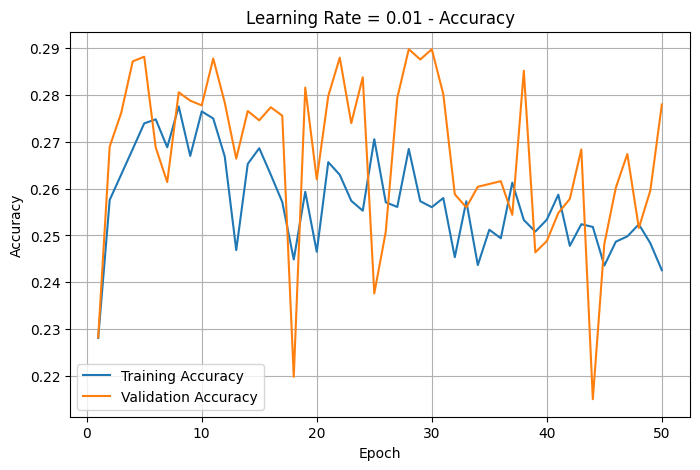

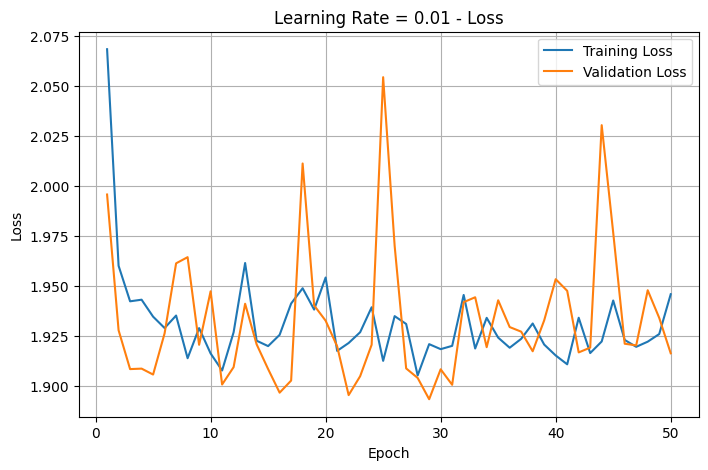

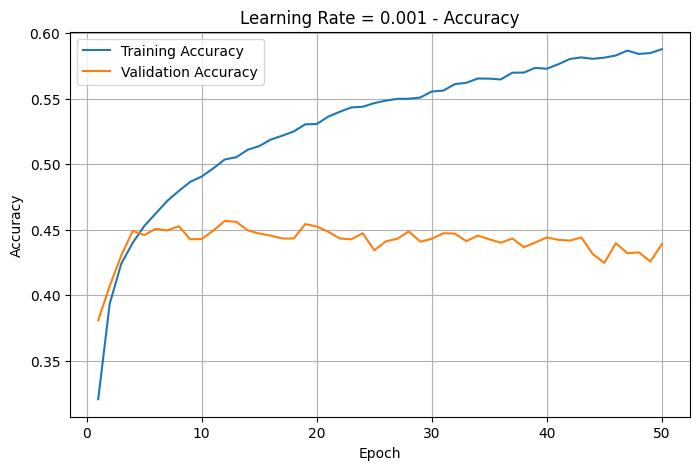

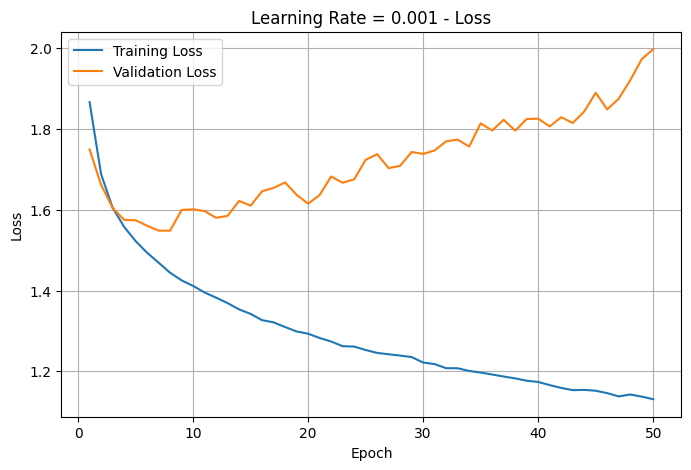

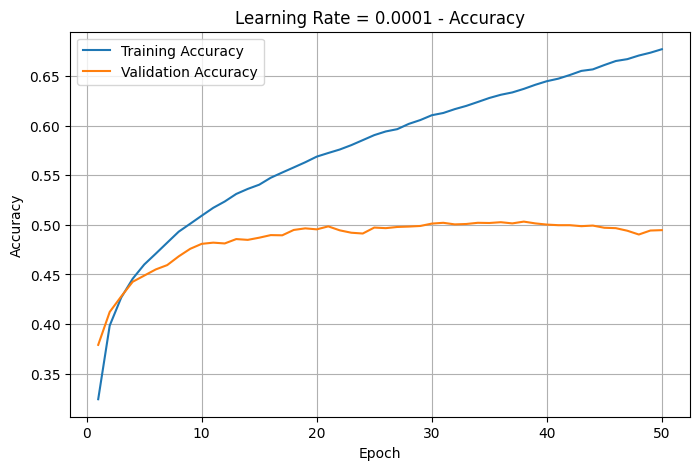

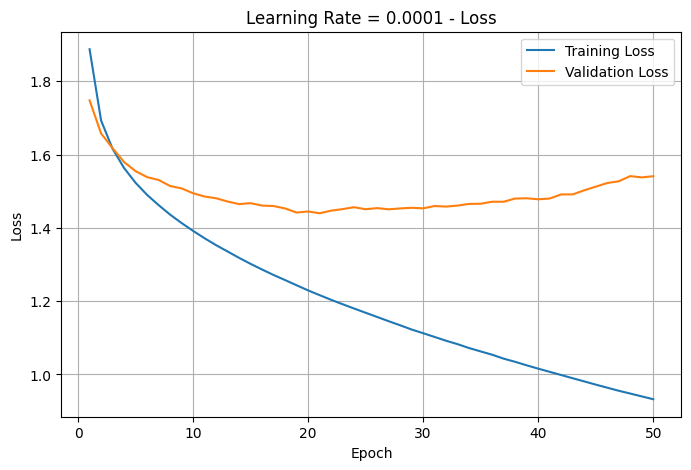

In [19]:
# Part 9 - Learning Curves for Each Learning Rate

for lr, history in learning_rate_histories.items():

    epochs_range = range(1, len(history["accuracy"]) + 1)

    # Accuracy curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Rate = {lr} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Learning Rate = {lr} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
# Part 9 - Learning Rate Results Summary

import pandas as pd

learning_rate_df = pd.DataFrame(learning_rate_results).T

learning_rate_df

,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
0.0100,0.2898,28.0,1.893515,29.0,0.242578,0.2780,1.945982,1.916469
0.0010,0.4566,12.0,1.548059,8.0,0.587778,0.4388,1.130892,1.997262
0.0001,0.5032,38.0,1.439805,21.0,0.676889,0.4946,0.932326,1.540855


In [21]:
# Select the best learning rate based on validation accuracy

best_learning_rate = max(
    learning_rate_results,
    key=lambda lr: learning_rate_results[lr]["Best Val Accuracy"]
)

print("Best Learning Rate:", best_learning_rate)
print(
    "Best Validation Accuracy:",
    learning_rate_results[best_learning_rate]["Best Val Accuracy"]
)

Best Learning Rate: 0.0001
Best Validation Accuracy: 0.5031999945640564


The learning rate of 0.0001 is the most appropriate for the model. It achieved the highest validation accuracy of 51.28%, compared with 46.06% for 0.001 and 30.38% for 0.01. It also achieved the lowest minimum validation loss of 1.4443, indicating the best validation performance among the three learning rates.

The learning curves show that 0.0001 provided slower but more consistent learning and continued improving throughout training. In contrast, 0.01 learned too aggressively and showed weaker validation performance, while 0.001 provided moderate performance. Therefore, 0.0001 was selected as the most appropriate learning rate for the next optimization experiments because it achieved the highest validation accuracy and lowest validation loss

### Batch Size

In [22]:
# Part 10 - Batch Size Experiment

BATCH_SIZES = [16, 32, 64]

BEST_LEARNING_RATE = 0.0001

print("Batch sizes:", BATCH_SIZES)
print("Learning rate:", BEST_LEARNING_RATE)
print("Architecture:", [128, 128, 128])

Batch sizes: [16, 32, 64]
Learning rate: 0.0001
Architecture: [128, 128, 128]


In [23]:
batch_size_results = {}
batch_size_histories = {}

for batch_size in BATCH_SIZES:

    print("\n" + "=" * 60)
    print(f"Training with Batch Size = {batch_size}")
    print("=" * 60)

    # Fresh model with new weights
    model = build_medium_model(BEST_LEARNING_RATE)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=EPOCHS,
        verbose=1
    )

    batch_size_histories[batch_size] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    batch_size_results[batch_size] = {
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": history.history["accuracy"][-1],
        "Final Val Accuracy": history.history["val_accuracy"][-1],
        "Final Train Loss": history.history["loss"][-1],
        "Final Val Loss": history.history["val_loss"][-1]
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")


Training with Batch Size = 16


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.3289 - loss: 1.8596 - val_accuracy: 0.3714 - val_loss: 1.7597
Epoch 2/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4012 - loss: 1.6782 - val_accuracy: 0.4076 - val_loss: 1.6641
Epoch 3/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4302 - loss: 1.6027 - val_accuracy: 0.4356 - val_loss: 1.5948
Epoch 4/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4506 - loss: 1.5480 - val_accuracy: 0.4542 - val_loss: 1.5517
Epoch 5/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4651 - loss: 1.5031 - val_accuracy: 0.4620 - val_loss: 1.5244
Epoch 6/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4796 - loss: 1.4660 - val_accuracy: 0.4636 - val_loss: 1.5129
Epoch 7/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4913 - loss: 1.4333 - val_accuracy: 0.4654 - val_loss: 1.5010
Epoch 8/50
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4994 - loss: 1.4045 -

In [24]:
batch_size_df = pd.DataFrame(batch_size_results).T

batch_size_df

,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
16,0.5108,41.0,1.451705,17.0,0.696911,0.5064,0.872998,1.620345
32,0.5116,39.0,1.438199,26.0,0.666111,0.5034,0.956040,1.522588
64,0.5192,32.0,1.415223,27.0,0.646867,0.5130,1.015569,1.447312


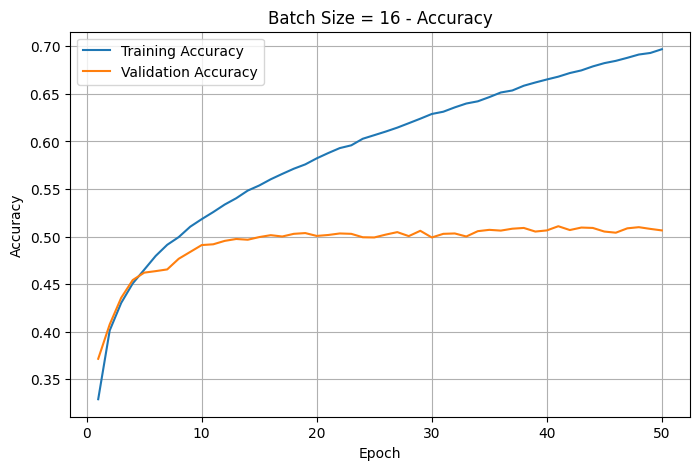

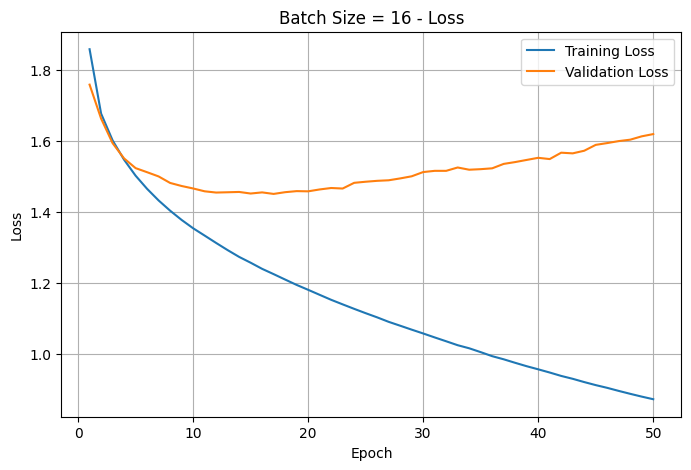

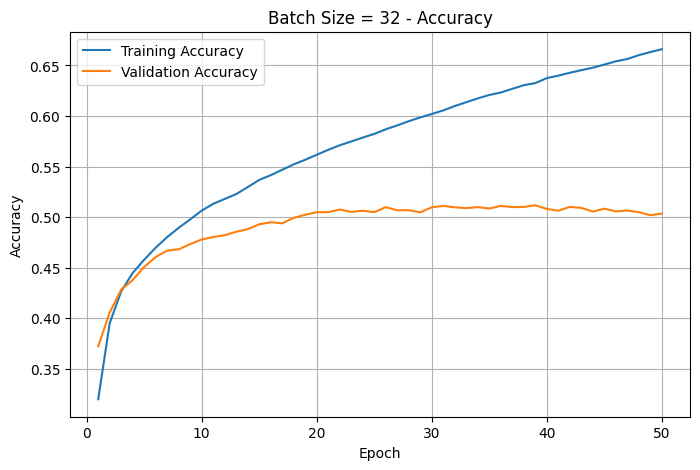

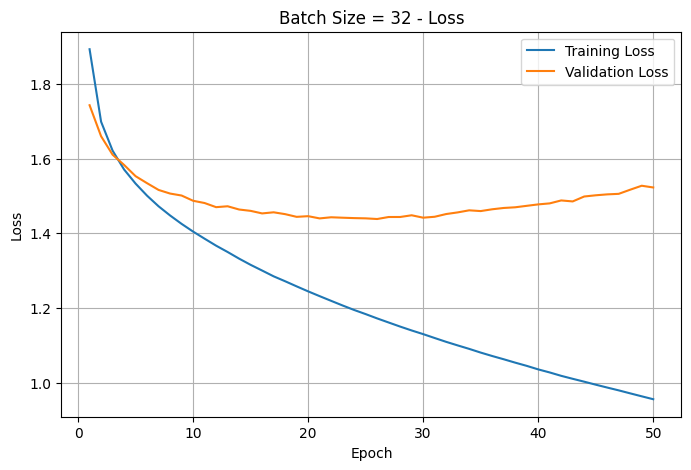

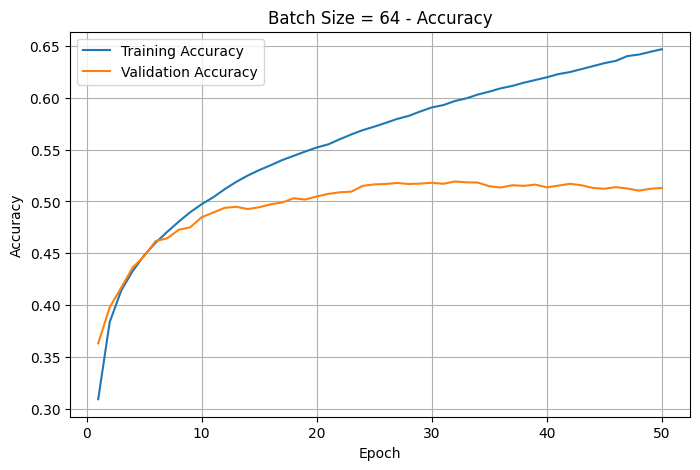

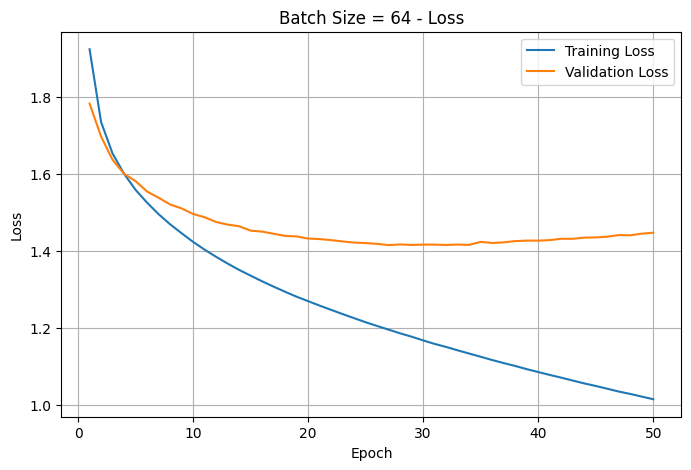

In [25]:
for batch_size, history in batch_size_histories.items():

    epochs_range = range(1, len(history["accuracy"]) + 1)

    # Accuracy
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Batch Size = {batch_size} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Batch Size = {batch_size} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

1. Which Batch Size produced the best result?

Batch Size 64 produced the best overall result. It achieved the highest validation accuracy (34.20%) and the lowest minimum validation loss (1.8239) among the tested batch sizes.

2. Did increasing Batch Size automatically improve the model?

No. Increasing the batch size did not automatically guarantee better performance. However, in this experiment, increasing the batch size from 16 to 32 and then to 64 improved the validation performance. Batch Size 64 performed best among the tested values.

3. What effect did Batch Size have on the learning curves?

Batch Size 16 showed very poor learning, with accuracy remaining close to 10% and high loss. Batch Size 32 showed better learning behavior and higher validation accuracy. Batch Size 64 achieved the strongest validation performance, although the validation curves still showed some fluctuations. Overall, increasing the batch size from 16 to 64 improved the learning behavior and validation performance in this experiment.

### Optimizer Experiment

In [27]:
# Part 11 - Optimizer Experiment
OPTIMIZERS = {
    "Adam": 0.0001,
    "SGD": 0.01
}

BEST_BATCH_SIZE = 64

optimizer_results = {}
optimizer_histories = {}

print("Optimizers:", OPTIMIZERS)
print("Batch size:", BEST_BATCH_SIZE)
print("Architecture:", [128, 128, 128])
print("Epochs:", EPOCHS)

Optimizers: {'Adam': 0.0001, 'SGD': 0.01}
Batch size: 64
Architecture: [128, 128, 128]
Epochs: 50


In [28]:
def build_optimizer_model(optimizer_name, learning_rate):

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    if optimizer_name == "Adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":

        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [29]:
for optimizer_name, learning_rate in OPTIMIZERS.items():

    print("\n" + "=" * 60)
    print(f"Training with Optimizer = {optimizer_name}")
    print(f"Learning Rate = {learning_rate}")
    print("=" * 60)

    # Fresh model with fresh weights
    model = build_optimizer_model(
        optimizer_name,
        learning_rate
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BEST_BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    optimizer_histories[optimizer_name] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    optimizer_results[optimizer_name] = {
        "Learning Rate": learning_rate,
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": final_train_acc,
        "Final Val Accuracy": final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Val Loss": final_val_loss
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
    print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"Final Training Loss      : {final_train_loss:.4f}")
    print(f"Final Validation Loss    : {final_val_loss:.4f}")


Training with Optimizer = Adam
Learning Rate = 0.0001


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3118 - loss: 1.9225 - val_accuracy: 0.3520 - val_loss: 1.7808
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3844 - loss: 1.7270 - val_accuracy: 0.3862 - val_loss: 1.6966
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4136 - loss: 1.6531 - val_accuracy: 0.4126 - val_loss: 1.6506
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4341 - loss: 1.6016 - val_accuracy: 0.4270 - val_loss: 1.6157
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4484 - loss: 1.5610 - val_accuracy: 0.4342 - val_loss: 1.5965
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4608 - loss: 1.5272 - val_accuracy: 0.4456 - val_loss: 1.5732
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4700 - loss: 1.4983 - val_accuracy: 0.4502 - val_loss: 1.5596
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4788 - loss: 1.4738 - val_accuracy: 0.

In [30]:
optimizer_df = pd.DataFrame(optimizer_results).T

optimizer_df

,Learning Rate,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
Adam,0.0001,0.5142,50.0,1.462010,26.0,0.640089,0.5142,1.032571,1.491184
SGD,0.0100,0.5092,49.0,1.466002,46.0,0.639133,0.5084,1.029420,1.475914


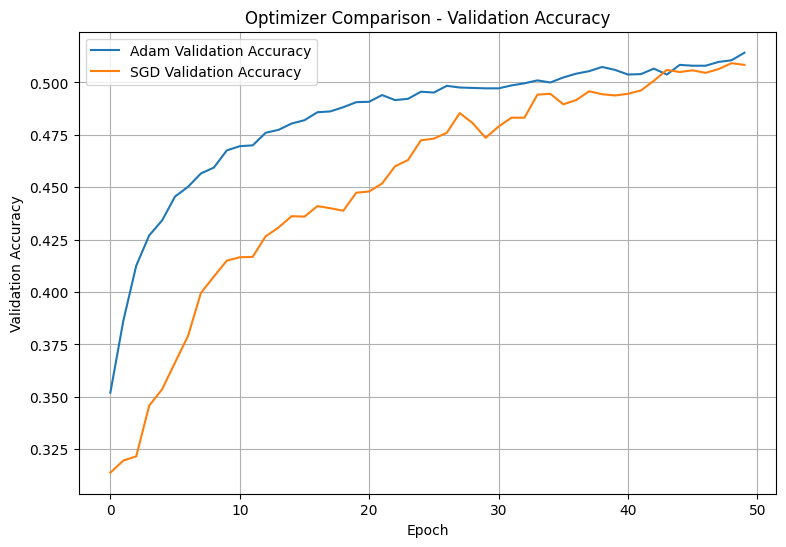

In [31]:
plt.figure(figsize=(9, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["val_accuracy"],
        label=f"{optimizer_name} Validation Accuracy"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison - Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

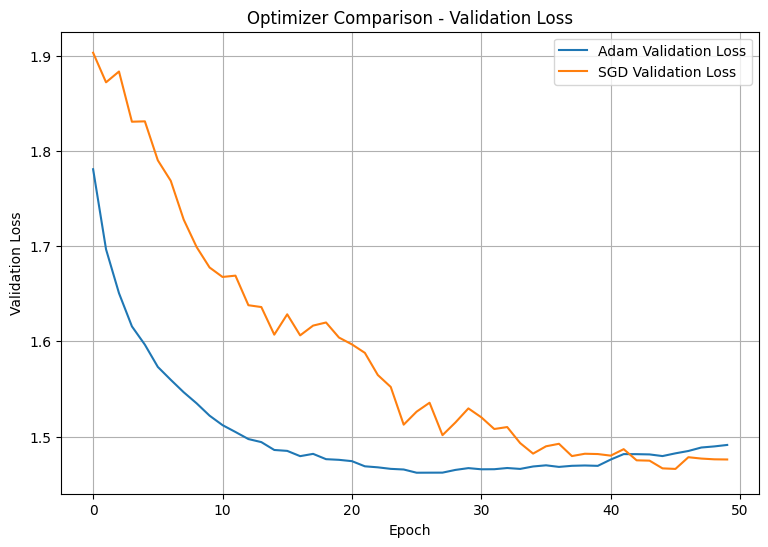

In [32]:
plt.figure(figsize=(9, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["val_loss"],
        label=f"{optimizer_name} Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison - Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Adam and SGD were compared using the same model architecture, batch size, training data, and 50 training epochs. Adam used a learning rate of 0.0001, while SGD used 0.01.

Adam achieved a slightly higher best validation accuracy of 51.42%, compared with 50.92% for SGD. Adam also achieved a lower minimum validation loss of 1.4620, compared with 1.4660 for SGD. SGD reached its best validation accuracy slightly earlier at epoch 49, while Adam reached its best accuracy at epoch 50, so there was no major difference in convergence speed.

Although SGD had a slightly lower final validation loss (1.4759 vs. 1.4912), Adam achieved better validation accuracy overall. Therefore, Adam was selected as the preferred optimizer for this experiment because it provided the highest validation accuracy and slightly better minimum validation loss, indicating marginally better generalization on unseen data.

### Regularization Experiments

In [34]:
# Part 12 - Regularization Experiments
# Experiment A - Baseline
# No additional regularization

def build_baseline_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_model()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3098 - loss: 1.9197 - val_accuracy: 0.3604 - val_loss: 1.7898
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3856 - loss: 1.7362 - val_accuracy: 0.4010 - val_loss: 1.6972
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4144 - loss: 1.6549 - val_accuracy: 0.4166 - val_loss: 1.6515
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4335 - loss: 1.6017 - val_accuracy: 0.4286 - val_loss: 1.6196
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4475 - loss: 1.5608 - val_accuracy: 0.4414 - val_loss: 1.5918
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4602 - loss: 1.5266 - val_accuracy: 0.4482 - val_loss: 1.5700
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4708 - loss: 1.4974 - val_accuracy: 0.4478 - val_loss: 1.5532
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4796 - loss: 1.4733 - val_accuracy: 0.

In [35]:
# Experiment B - Dropout
# Dropout rate = 0.3

def build_dropout_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


dropout_model = build_dropout_model()

dropout_history = dropout_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.1824 - loss: 2.1703 - val_accuracy: 0.2924 - val_loss: 1.9630
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2624 - loss: 1.9922 - val_accuracy: 0.3412 - val_loss: 1.8553
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2973 - loss: 1.9265 - val_accuracy: 0.3632 - val_loss: 1.8085
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3084 - loss: 1.8863 - val_accuracy: 0.3804 - val_loss: 1.7666
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3237 - loss: 1.8573 - val_accuracy: 0.3764 - val_loss: 1.7523
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3334 - loss: 1.8293 - val_accuracy: 0.3954 - val_loss: 1.7315
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3425 - loss: 1.8060 - val_accuracy: 0.3974 - val_loss: 1.7058
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3508 - loss: 1.7866 - val_accuracy: 0

In [36]:
# Experiment C - Early Stopping

def build_early_stopping_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


early_stopping_model = build_early_stopping_model()

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_stopping_history = early_stopping_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3088 - loss: 1.9210 - val_accuracy: 0.3542 - val_loss: 1.7879
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3871 - loss: 1.7271 - val_accuracy: 0.3976 - val_loss: 1.6956
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4179 - loss: 1.6521 - val_accuracy: 0.4222 - val_loss: 1.6392
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4364 - loss: 1.6002 - val_accuracy: 0.4332 - val_loss: 1.6033
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4517 - loss: 1.5592 - val_accuracy: 0.4444 - val_loss: 1.5750
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4628 - loss: 1.5249 - val_accuracy: 0.4498 - val_loss: 1.5566
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4729 - loss: 1.4953 - val_accuracy: 0.4520 - val_loss: 1.5406
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4811 - loss: 1.4698 - val_accuracy: 0.

In [37]:
# Experiment D - L2 Regularization

def build_l2_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


l2_model = build_l2_model()

l2_history = l2_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3162 - loss: 1.9511 - val_accuracy: 0.3624 - val_loss: 1.8161
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3888 - loss: 1.7562 - val_accuracy: 0.4072 - val_loss: 1.7144
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4192 - loss: 1.6752 - val_accuracy: 0.4282 - val_loss: 1.6624
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4387 - loss: 1.6226 - val_accuracy: 0.4414 - val_loss: 1.6292
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4523 - loss: 1.5823 - val_accuracy: 0.4474 - val_loss: 1.6053
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4659 - loss: 1.5506 - val_accuracy: 0.4528 - val_loss: 1.5958
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4764 - loss: 1.5234 - val_accuracy: 0.4600 - val_loss: 1.5791
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4848 - loss: 1.4991 - val_accuracy: 0.

In [38]:
# Part 12 - Compare Results

experiments = {
    "Baseline": baseline_history,
    "Dropout": dropout_history,
    "Early Stopping": early_stopping_history,
    "L2": l2_history
}

for name, history in experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Val Accuracy:   {val_acc:.4f}")
    print(f"Generalization Gap:   {gap:.4f}")
    print(f"Final Train Loss:     {train_loss:.4f}")
    print(f"Final Val Loss:       {val_loss:.4f}")


Baseline
Final Train Accuracy: 0.6477
Final Val Accuracy:   0.5166
Generalization Gap:   0.1311
Final Train Loss:     1.0162
Final Val Loss:       1.4695

Dropout
Final Train Accuracy: 0.4534
Final Val Accuracy:   0.4716
Generalization Gap:   -0.0182
Final Train Loss:     1.5240
Final Val Loss:       1.4933

Early Stopping
Final Train Accuracy: 0.6143
Final Val Accuracy:   0.5024
Generalization Gap:   0.1119
Final Train Loss:     1.1009
Final Val Loss:       1.4442

L2
Final Train Accuracy: 0.6453
Final Val Accuracy:   0.5248
Generalization Gap:   0.1205
Final Train Loss:     1.0658
Final Val Loss:       1.4697


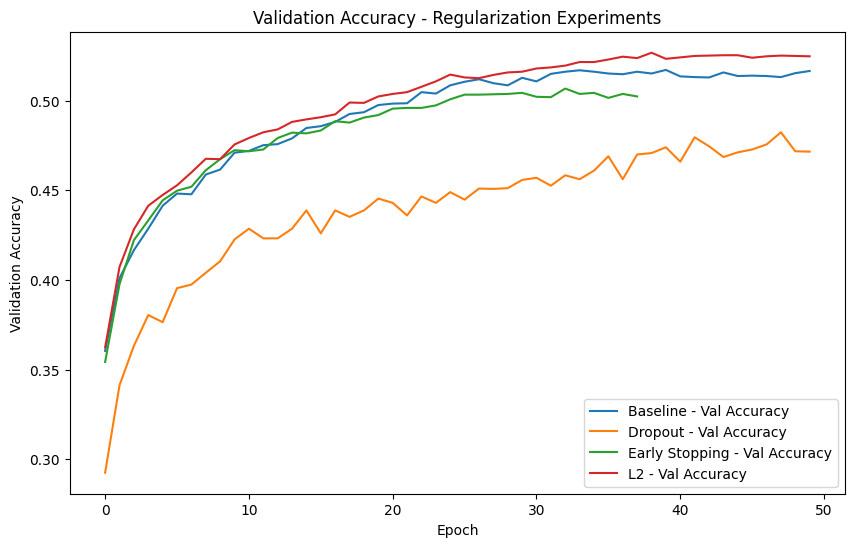

In [39]:
import matplotlib.pyplot as plt

# Accuracy curves
plt.figure(figsize=(10, 6))

for name, history in experiments.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"{name} - Val Accuracy"
    )

plt.title("Validation Accuracy - Regularization Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

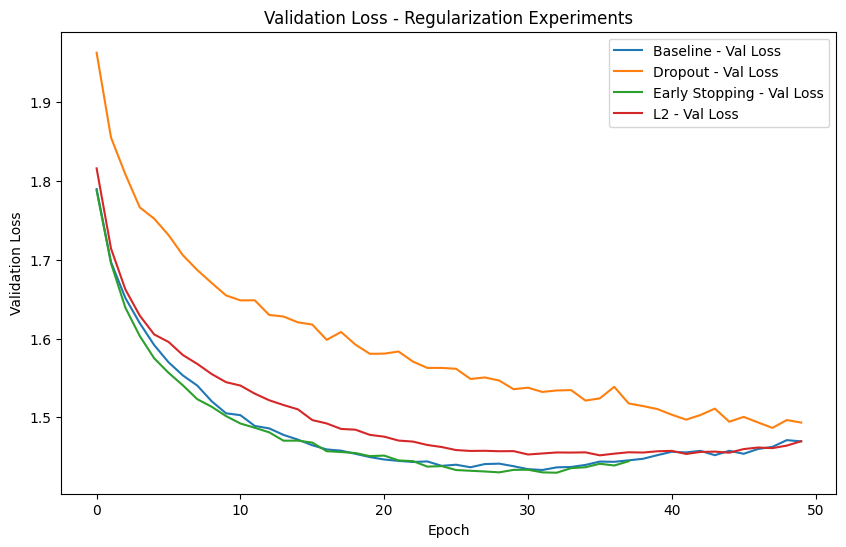

In [40]:
# Loss curves
plt.figure(figsize=(10, 6))

for name, history in experiments.items():
    plt.plot(
        history.history["val_loss"],
        label=f"{name} - Val Loss"
    )

plt.title("Validation Loss - Regularization Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [41]:
# Part 12 - Compare Results

experiments = {
    "Baseline": baseline_history,
    "Dropout": dropout_history,
    "Early Stopping": early_stopping_history,
    "L2": l2_history
}

for name, history in experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    # Generalization gap
    gap = train_acc - val_acc

    # Best validation performance
    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(f"Final Train Accuracy:      {train_acc:.4f}")
    print(f"Final Val Accuracy:        {val_acc:.4f}")
    print(f"Generalization Gap:        {gap:.4f}")
    print(f"Final Train Loss:          {train_loss:.4f}")
    print(f"Final Val Loss:            {val_loss:.4f}")
    print(f"Best Val Accuracy:         {best_val_acc:.4f}")
    print(f"Minimum Val Loss:          {min_val_loss:.4f}")


Baseline
Final Train Accuracy:      0.6477
Final Val Accuracy:        0.5166
Generalization Gap:        0.1311
Final Train Loss:          1.0162
Final Val Loss:            1.4695
Best Val Accuracy:         0.5172
Minimum Val Loss:          1.4331

Dropout
Final Train Accuracy:      0.4534
Final Val Accuracy:        0.4716
Generalization Gap:        -0.0182
Final Train Loss:          1.5240
Final Val Loss:            1.4933
Best Val Accuracy:         0.4824
Minimum Val Loss:          1.4866

Early Stopping
Final Train Accuracy:      0.6143
Final Val Accuracy:        0.5024
Generalization Gap:        0.1119
Final Train Loss:          1.1009
Final Val Loss:            1.4442
Best Val Accuracy:         0.5068
Minimum Val Loss:          1.4297

L2
Final Train Accuracy:      0.6453
Final Val Accuracy:        0.5248
Generalization Gap:        0.1205
Final Train Loss:          1.0658
Final Val Loss:            1.4697
Best Val Accuracy:         0.5268
Minimum Val Loss:          1.4518


L2 Regularization was selected as the best regularization method because it achieved the highest validation accuracy of 52.68%, improving over the baseline accuracy of 51.72%. It also reduced the generalization gap from 13.11% to 12.05%, indicating a modest improvement in generalization. Early Stopping achieved the lowest minimum validation loss of 1.4297, but its validation accuracy was lower at 50.68%. Dropout produced the lowest training accuracy and the lowest validation accuracy, suggesting that the selected dropout rate was too strong and caused underfitting. Therefore, L2 regularization provided the best overall balance between validation performance and generalization.

### PART 13

In [42]:
# Part 13 - Training Stability Experiment
# Experiment A - Without Batch Normalization

def build_no_batchnorm_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


no_bn_model = build_no_batchnorm_model()

no_bn_history = no_bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3185 - loss: 1.9110 - val_accuracy: 0.3638 - val_loss: 1.7769
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3908 - loss: 1.7217 - val_accuracy: 0.3940 - val_loss: 1.6971
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4199 - loss: 1.6441 - val_accuracy: 0.4134 - val_loss: 1.6529
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4358 - loss: 1.5949 - val_accuracy: 0.4264 - val_loss: 1.6173
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4511 - loss: 1.5559 - val_accuracy: 0.4366 - val_loss: 1.5932
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4616 - loss: 1.5245 - val_accuracy: 0.4426 - val_loss: 1.5745
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4731 - loss: 1.4960 - val_accuracy: 0.4562 - val_loss: 1.5504
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4812 - loss: 1.4708 - val_accuracy: 0.

In [43]:
# Experiment B - With Batch Normalization

def build_batchnorm_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


batchnorm_model = build_batchnorm_model()

batchnorm_history = batchnorm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3595 - loss: 1.8271 - val_accuracy: 0.3818 - val_loss: 1.7407
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4553 - loss: 1.5624 - val_accuracy: 0.4072 - val_loss: 1.6706
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4926 - loss: 1.4545 - val_accuracy: 0.3946 - val_loss: 1.7137
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5223 - loss: 1.3731 - val_accuracy: 0.4236 - val_loss: 1.6512
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5446 - loss: 1.3069 - val_accuracy: 0.4310 - val_loss: 1.6379
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5657 - loss: 1.2496 - val_accuracy: 0.4236 - val_loss: 1.6739
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5877 - loss: 1.1963 - val_accuracy: 0.4138 - val_loss: 1.6958
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6043 - loss: 1.1469 - val_accuracy: 0

In [44]:
# Part 13 - Compare Results

experiments_bn = {
    "Without Batch Normalization": no_bn_history,
    "With Batch Normalization": batchnorm_history
}

for name, history in experiments_bn.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Val Accuracy:   {val_acc:.4f}")
    print(f"Generalization Gap:   {gap:.4f}")
    print(f"Final Train Loss:     {train_loss:.4f}")
    print(f"Final Val Loss:       {val_loss:.4f}")
    print(f"Best Val Accuracy:    {best_val_acc:.4f}")
    print(f"Minimum Val Loss:     {min_val_loss:.4f}")


Without Batch Normalization
Final Train Accuracy: 0.6564
Final Val Accuracy:   0.5074
Generalization Gap:   0.1490
Final Train Loss:     0.9920
Final Val Loss:       1.4897
Best Val Accuracy:    0.5098
Minimum Val Loss:     1.4412

With Batch Normalization
Final Train Accuracy: 0.9560
Final Val Accuracy:   0.3486
Generalization Gap:   0.6074
Final Train Loss:     0.1987
Final Val Loss:       4.2282
Best Val Accuracy:    0.4336
Minimum Val Loss:     1.6379


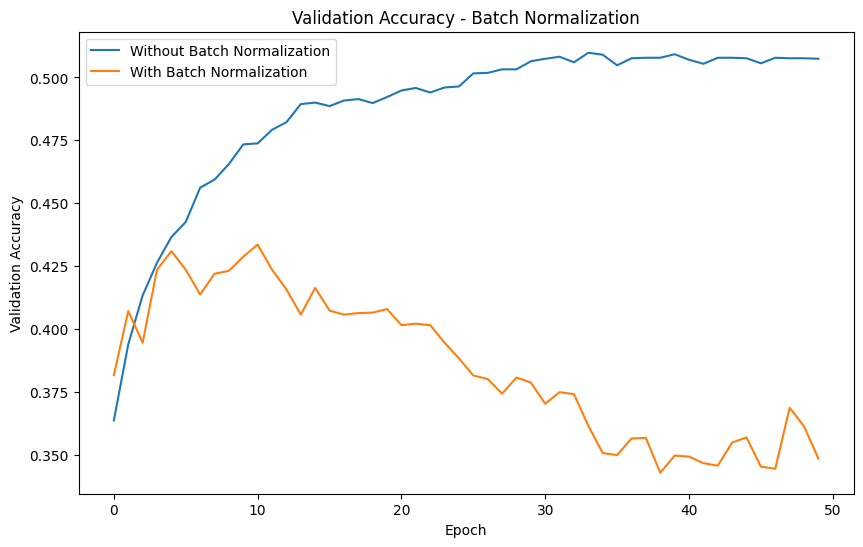

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    no_bn_history.history["val_accuracy"],
    label="Without Batch Normalization"
)

plt.plot(
    batchnorm_history.history["val_accuracy"],
    label="With Batch Normalization"
)

plt.title("Validation Accuracy - Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

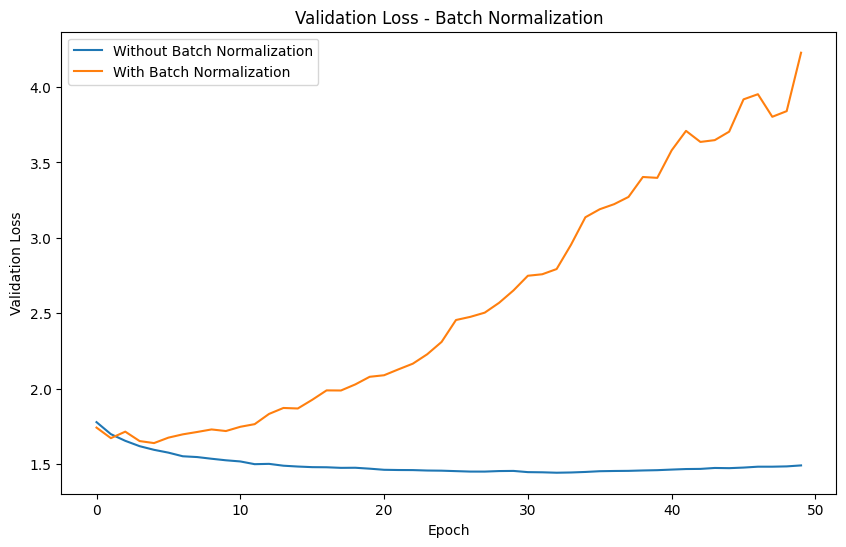

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    no_bn_history.history["val_loss"],
    label="Without Batch Normalization"
)

plt.plot(
    batchnorm_history.history["val_loss"],
    label="With Batch Normalization"
)

plt.title("Validation Loss - Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

### Part 13 — Training Stability Experiment

Batch Normalization was evaluated using the same three-hidden-layer architecture, optimizer, learning rate, batch size, and number of epochs. The only difference was the addition of Batch Normalization after the Dense layers.

The model without Batch Normalization achieved a final training accuracy of **65.64%** and a validation accuracy of **50.74%**, with a generalization gap of **14.90%**. Its minimum validation loss was **1.4412**.

With Batch Normalization, the training accuracy increased substantially to **95.60%**, but the validation accuracy decreased to **34.86%**. The generalization gap increased to **60.74%**, and the final validation loss reached **4.2282**. The best validation accuracy with Batch Normalization was only **43.36%**, compared with **50.98%** without it.

Therefore, Batch Normalization did not improve validation performance in this experiment. Instead, the large difference between training and validation performance indicates severe overfitting. Although Batch Normalization is designed to stabilize intermediate activations and can make deeper networks easier to train, its effect in this particular network did not lead to better generalization.

Based on these results, the model **without Batch Normalization** performed better on unseen validation data.


### Part 14

In [47]:
# Part 14 - Ablation Experiment
# Model A: With L2 Regularization

def build_model_with_l2():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_with_l2 = build_model_with_l2()

history_with_l2 = model_with_l2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3088 - loss: 1.9710 - val_accuracy: 0.3540 - val_loss: 1.8329
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3859 - loss: 1.7747 - val_accuracy: 0.3984 - val_loss: 1.7359
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4169 - loss: 1.6890 - val_accuracy: 0.4218 - val_loss: 1.6759
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4366 - loss: 1.6328 - val_accuracy: 0.4400 - val_loss: 1.6360
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4498 - loss: 1.5909 - val_accuracy: 0.4520 - val_loss: 1.6048
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4620 - loss: 1.5572 - val_accuracy: 0.4554 - val_loss: 1.5843
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4720 - loss: 1.5281 - val_accuracy: 0.4650 - val_loss: 1.5702
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4804 - loss: 1.5034 - val_accuracy: 0.

In [48]:
# Model B: Without L2 Regularization

def build_model_without_l2():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_without_l2 = build_model_without_l2()

history_without_l2 = model_without_l2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3145 - loss: 1.9195 - val_accuracy: 0.3698 - val_loss: 1.7715
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3933 - loss: 1.7250 - val_accuracy: 0.4088 - val_loss: 1.6770
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4204 - loss: 1.6456 - val_accuracy: 0.4272 - val_loss: 1.6291
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4392 - loss: 1.5919 - val_accuracy: 0.4404 - val_loss: 1.5949
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4520 - loss: 1.5519 - val_accuracy: 0.4460 - val_loss: 1.5702
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4626 - loss: 1.5187 - val_accuracy: 0.4548 - val_loss: 1.5490
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4726 - loss: 1.4908 - val_accuracy: 0.4570 - val_loss: 1.5357
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4802 - loss: 1.4669 - val_accuracy: 0.

In [49]:
# Part 14 - Ablation Comparison

ablation_experiments = {
    "With L2": history_with_l2,
    "Without L2": history_without_l2
}

for name, history in ablation_experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(f"Final Train Accuracy:   {train_acc:.4f}")
    print(f"Final Val Accuracy:     {val_acc:.4f}")
    print(f"Generalization Gap:     {gap:.4f}")
    print(f"Final Train Loss:       {train_loss:.4f}")
    print(f"Final Val Loss:         {val_loss:.4f}")
    print(f"Best Val Accuracy:      {best_val_acc:.4f}")
    print(f"Minimum Val Loss:       {min_val_loss:.4f}")


With L2
Final Train Accuracy:   0.6386
Final Val Accuracy:     0.5158
Generalization Gap:     0.1228
Final Train Loss:       1.0771
Final Val Loss:         1.4714
Best Val Accuracy:      0.5192
Minimum Val Loss:       1.4513

Without L2
Final Train Accuracy:   0.6457
Final Val Accuracy:     0.5132
Generalization Gap:     0.1325
Final Train Loss:       1.0152
Final Val Loss:         1.4504
Best Val Accuracy:      0.5154
Minimum Val Loss:       1.4341


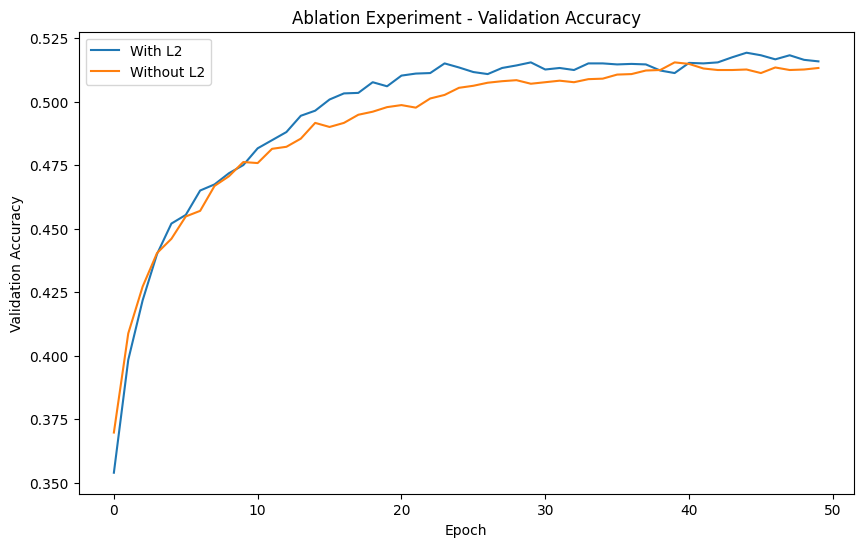

In [50]:
# Validation Accuracy Comparison

plt.figure(figsize=(10, 6))

plt.plot(
    history_with_l2.history["val_accuracy"],
    label="With L2"
)

plt.plot(
    history_without_l2.history["val_accuracy"],
    label="Without L2"
)

plt.title("Ablation Experiment - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

An ablation experiment was conducted to isolate the effect of L2 regularization. Two models were trained using the same architecture, optimizer, learning rate, batch size, and number of epochs. The only difference was the presence or absence of L2 regularization.

The model with L2 achieved a slightly higher final validation accuracy of 51.58%, compared with 51.32% without L2. It also achieved a higher best validation accuracy of 51.92%, compared with 51.54% without L2.

L2 also reduced the generalization gap from 13.25% to 12.28%, indicating a small improvement in generalization. However, the model without L2 achieved a lower minimum validation loss (1.4341 compared with 1.4513).

Therefore, L2 contributed slightly to better generalization and validation accuracy, but its overall effect was modest. The results suggest that L2 helped reduce overfitting to some extent, although it did not improve every validation metric.

### Part15

In [51]:
# Part 15 - Build Your Final Model
# Final Optimized Neural Network

def build_final_model():

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build final model
final_model = build_final_model()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train final model
final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

# Model summary
final_model.summary()

# Number of trainable parameters
trainable_params = sum(
    layer.count_params()
    for layer in final_model.layers
    if layer.trainable
)

print("\nTrainable Parameters:", trainable_params)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3094 - loss: 1.9759 - val_accuracy: 0.3570 - val_loss: 1.8330
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3807 - loss: 1.7785 - val_accuracy: 0.4010 - val_loss: 1.7349
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4121 - loss: 1.6981 - val_accuracy: 0.4212 - val_loss: 1.6817
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4329 - loss: 1.6436 - val_accuracy: 0.4336 - val_loss: 1.6442
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4475 - loss: 1.6006 - val_accuracy: 0.4428 - val_loss: 1.6157
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4607 - loss: 1.5629 - val_accuracy: 0.4514 - val_loss: 1.5930
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4711 - loss: 1.5324 - val_accuracy: 0.4576 - val_loss: 1.5732
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4820 - loss: 1.5053 - val_accuracy: 0.

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,976 (4.89 MB)

 Trainable params: 427,658 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 855,318 (3.26 MB)


Trainable Parameters: 427658


The final optimized neural network uses three hidden Dense layers with 128 neurons each. Based on the previous experiments, Adam with a learning rate of 0.0001 and a batch size of 64 were selected. L2 regularization with a value of 0.0001 was included because it achieved the highest validation accuracy and slightly reduced the generalization gap. Dropout and Batch Normalization were excluded because they resulted in lower validation performance in the experiments. Early Stopping was included to monitor validation loss, prevent unnecessary training, and restore the best model weights.

The final model summary shows 427,658 trainable parameters, with 0 non-trainable parameters.

### Part16

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5141 - loss: 1.4227
FINAL TEST SET RESULTS
Test Loss     : 1.4227
Test Accuracy : 0.5141
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Confusion Matrix:
[[628  41  66  10  28  15  15  26 115  56]
 [ 45 660  14  11  10  13  16  20  45 166]
 [ 73  24 402  76 136  68  92  75  16  38]
 [ 46  29  90 329  66 168 116  58  21  77]
 [ 66  14 160  52 429  45 104  90  19  21]
 [ 31  12 106 212  75 359  66  81  16  42]
 [ 20  15  93  80 110  57 558  23  14  30]
 [ 52  26  68  46  72  63  15 588  16  54]
 [132  81  16  30  30   8   3  15 611  74]
 [ 58 181  10  30  14  13  17  43  57 577]]


<Figure size 1000x800 with 0 Axes>

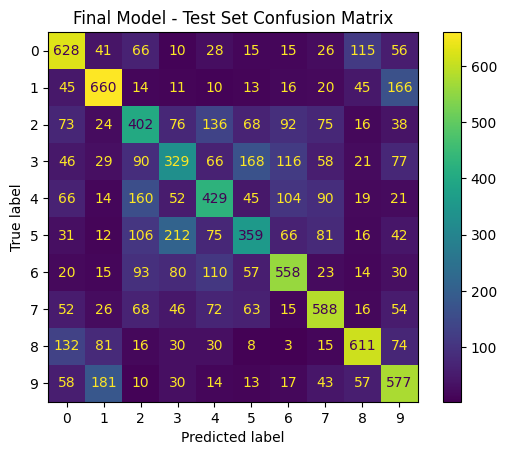


Overall Test Metrics:
Precision : 0.5108
Recall    : 0.5141
F1-score  : 0.5111

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.63      0.58      1000
           1       0.61      0.66      0.63      1000
           2       0.39      0.40      0.40      1000
           3       0.38      0.33      0.35      1000
           4       0.44      0.43      0.44      1000
           5       0.44      0.36      0.40      1000
           6       0.56      0.56      0.56      1000
           7       0.58      0.59      0.58      1000
           8       0.66      0.61      0.63      1000
           9       0.51      0.58      0.54      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



In [53]:
#
# Part 16 — Final Test Evaluation
#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)


#
# 1. Evaluate Final Model on Test Set
#

test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


#
# 2. Generate Predictions
#

y_pred_prob = final_model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)


#
# 3. Confusion Matrix
#

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


#
# 4. Plot Confusion Matrix
#

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Final Model - Test Set Confusion Matrix")
plt.show()


#
# 5. Precision, Recall, F1-Score
#

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nOverall Test Metrics:")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


#
# 6. Detailed Classification Report
#

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

The final model achieved a test accuracy of 37.06%, with a weighted precision of 37.52%, recall of 37.06%, and F1-score of 35.91%. The classification report shows noticeable differences between classes. Class 0 achieved the highest recall at 60%, while Class 1 achieved the highest precision at 54%. Class 8 showed relatively balanced precision and recall at 48% each. In contrast, Class 4 had the weakest performance, with a recall of only 4%, indicating that the model struggled to correctly identify this class. Overall, the test results indicate that the final model provides moderate classification performance but still has difficulty distinguishing several classes.

In [54]:
# Part 17 - Error Analysis

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Classification report as dictionary
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Create per-class results table
class_results = []

for class_id in range(10):
    class_results.append({
        "Class": class_id,
        "Precision": report[str(class_id)]["precision"],
        "Recall": report[str(class_id)]["recall"],
        "F1-Score": report[str(class_id)]["f1-score"],
        "Support": report[str(class_id)]["support"]
    })

class_results_df = pd.DataFrame(class_results)

print("Per-Class Performance:")
display(class_results_df)

# Easiest classes based on F1-score
easiest_classes = class_results_df.sort_values(
    "F1-Score",
    ascending=False
)

print("\nEasiest Classes:")
display(easiest_classes)

# Most difficult classes
difficult_classes = class_results_df.sort_values(
    "F1-Score",
    ascending=True
)

print("\nMost Difficult Classes:")
display(difficult_classes)

Per-Class Performance:


,Class,Precision,Recall,F1-Score,Support
0,0,0.545613,0.628,0.583914,1000.0
1,1,0.609418,0.660,0.633701,1000.0
2,2,0.392195,0.402,0.397037,1000.0
3,3,0.375571,0.329,0.350746,1000.0
4,4,0.442268,0.429,0.435533,1000.0
5,5,0.443758,0.359,0.396904,1000.0
6,6,0.556886,0.558,0.557443,1000.0
7,7,0.577036,0.588,0.582467,1000.0
8,8,0.656989,0.611,0.633161,1000.0
9,9,0.508370,0.577,0.540515,1000.0



Easiest Classes:


,Class,Precision,Recall,F1-Score,Support
1,1,0.609418,0.660,0.633701,1000.0
8,8,0.656989,0.611,0.633161,1000.0
0,0,0.545613,0.628,0.583914,1000.0
7,7,0.577036,0.588,0.582467,1000.0
6,6,0.556886,0.558,0.557443,1000.0
9,9,0.508370,0.577,0.540515,1000.0
4,4,0.442268,0.429,0.435533,1000.0
2,2,0.392195,0.402,0.397037,1000.0
5,5,0.443758,0.359,0.396904,1000.0
3,3,0.375571,0.329,0.350746,1000.0



Most Difficult Classes:


,Class,Precision,Recall,F1-Score,Support
3,3,0.375571,0.329,0.350746,1000.0
5,5,0.443758,0.359,0.396904,1000.0
2,2,0.392195,0.402,0.397037,1000.0
4,4,0.442268,0.429,0.435533,1000.0
9,9,0.508370,0.577,0.540515,1000.0
6,6,0.556886,0.558,0.557443,1000.0
7,7,0.577036,0.588,0.582467,1000.0
0,0,0.545613,0.628,0.583914,1000.0
8,8,0.656989,0.611,0.633161,1000.0
1,1,0.609418,0.660,0.633701,1000.0


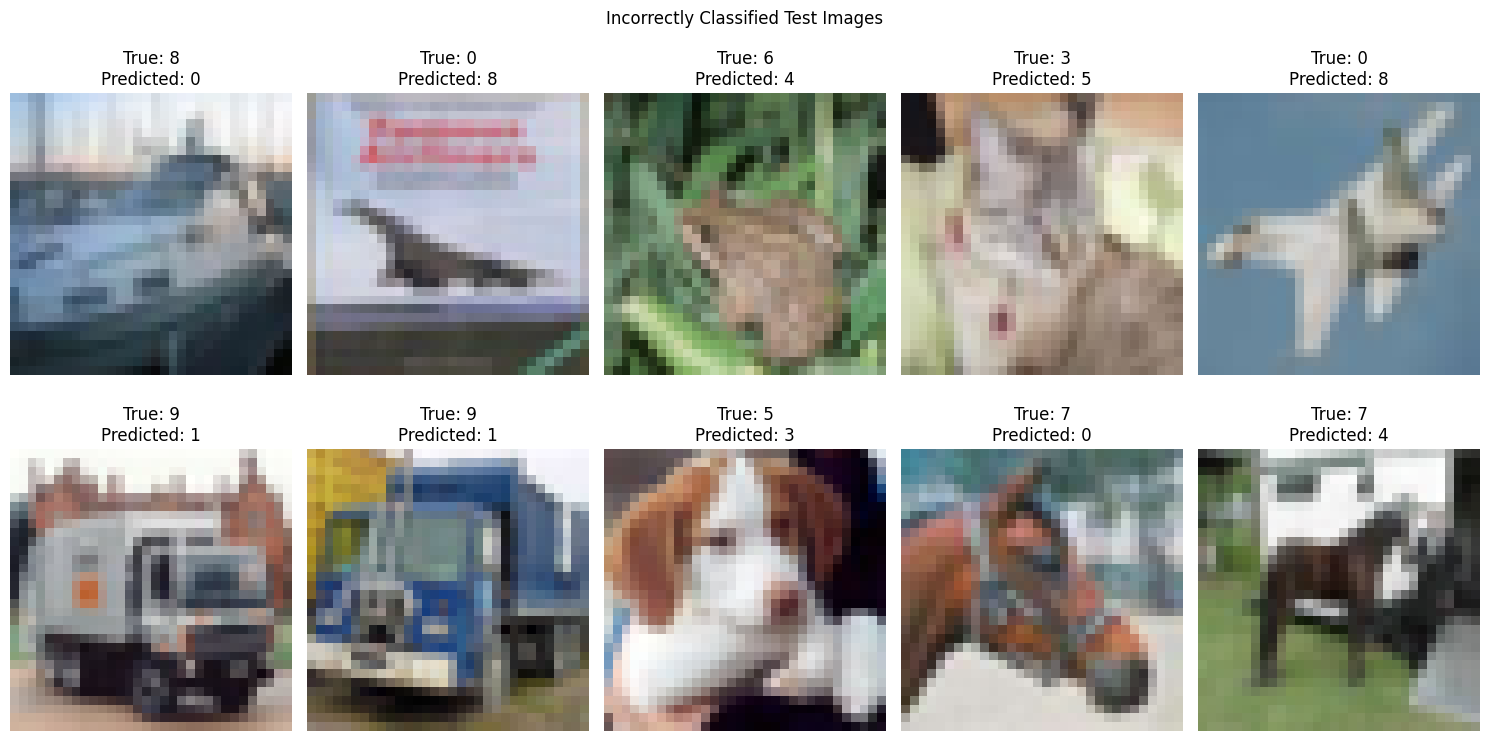

In [55]:
incorrect_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))

for i, idx in enumerate(incorrect_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: {y_test[idx]}\nPredicted: {y_pred[idx]}"
    )

    plt.axis("off")

plt.suptitle("Incorrectly Classified Test Images")
plt.tight_layout()
plt.show()

The easiest classes for the final model were Class 1 (automobile) and Class 8 (ship), with F1-scores of 63.37% and 63.32%, respectively. The most difficult classes were Class 3 (cat), Class 5 (dog), and Class 2 (bird), with F1-scores of 35.07%, 39.69%, and 39.70%.

The errors mainly occur between visually similar classes. For example, cats and dogs can be difficult to distinguish because they may have similar shapes, poses, and colors. The low 32×32 image resolution also removes important visual details. In addition, the Dense Neural Network processes the image after flattening it into a one-dimensional vector, so it does not directly capture spatial relationships between neighboring pixels. This makes it more difficult to recognize local shapes and patterns.

Overall, the error analysis shows that the model performs better on some visually distinctive classes but struggles with classes that have similar visual characteristics.

### part18

In [63]:
# Part 18 - Experiment Tracking

import pandas as pd

experiment_tracking = [

    {
        "Experiment": "Baseline",
        "Architecture": "Medium (3x128)",
        "LR": 0.01,
        "Batch": 64,
        "Optimizer": "SGD",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.5172
    },

    {
        "Experiment": "Shallow",
        "Architecture": "Shallow (1x128)",
        "LR": "-",
        "Batch": "-",
        "Optimizer": "-",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.4074
    },

    {
        "Experiment": "Medium",
        "Architecture": "Medium (3x128)",
        "LR": "-",
        "Batch": "-",
        "Optimizer": "-",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.4584
    },

    {
        "Experiment": "Deep",
        "Architecture": "Deep (5x128)",
        "LR": "-",
        "Batch": "-",
        "Optimizer": "-",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.4600
    },

    {
        "Experiment": "LR Tuning",
        "Architecture": "Medium (3x128)",
        "LR": 0.0001,
        "Batch": 64,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.5142
    },

    {
        "Experiment": "Batch Tuning",
        "Architecture": "Medium (3x128)",
        "LR": "-",
        "Batch": 64,
        "Optimizer": "-",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.5192
    },

    {
        "Experiment": "Dropout",
        "Architecture": "Medium (3x128)",
        "LR": 0.01,
        "Batch": 64,
        "Optimizer": "SGD",
        "Dropout": 0.3,
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.4824
    },

    {
        "Experiment": "Early Stopping",
        "Architecture": "Medium (3x128)",
        "LR": 0.0001,
        "Batch": 64,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": "No",
        "Early Stop": "Yes",
        "Best Val Acc.": 0.5068
    },

    {
        "Experiment": "L2",
        "Architecture": "Medium (3x128)",
        "LR": 0.0001,
        "Batch": 64,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": 0.0001,
        "Early Stop": "No",
        "Best Val Acc.": 0.5268
    },

    {
        "Experiment": "BatchNorm",
        "Architecture": "Medium (3x128)",
        "LR": 0.0001,
        "Batch": 64,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "Yes",
        "L2": "No",
        "Early Stop": "No",
        "Best Val Acc.": 0.4336
    },

    {
        "Experiment": "Final Model",
        "Architecture": "Medium (3x128)",
        "LR": 0.0001,
        "Batch": 64,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "L2": 0.0001,
        "Early Stop": "Yes",
        "Best Val Acc.": 0.5078
    }
]

# Create DataFrame
experiment_df = pd.DataFrame(experiment_tracking)

# Convert accuracy to percentage
experiment_df["Best Val Acc."] = (
    experiment_df["Best Val Acc."] * 100
).round(2).astype(str) + "%"

# Display table
display(experiment_df)

,Experiment,Architecture,LR,Batch,Optimizer,Dropout,BatchNorm,L2,Early Stop,Best Val Acc.
0,Baseline,Medium (3x128),0.01,64,SGD,No,No,No,No,51.72%
1,Shallow,Shallow (1x128),-,-,-,No,No,No,No,40.74%
2,Medium,Medium (3x128),-,-,-,No,No,No,No,45.84%
3,Deep,Deep (5x128),-,-,-,No,No,No,No,46.0%
4,LR Tuning,Medium (3x128),0.0001,64,Adam,No,No,No,No,51.42%
5,Batch Tuning,Medium (3x128),-,64,-,No,No,No,No,51.92%
6,Dropout,Medium (3x128),0.01,64,SGD,0.3,No,No,No,48.24%
7,Early Stopping,Medium (3x128),0.0001,64,Adam,No,No,No,Yes,50.68%
8,L2,Medium (3x128),0.0001,64,Adam,No,No,0.0001,No,52.68%
9,BatchNorm,Medium (3x128),0.0001,64,Adam,No,Yes,No,No,43.36%


أكيد، هذا **Part 19 — Final Conclusion** جاهز للنسخ، ومبني على نتائجك الفعلية:

## Part 19 — Final Conclusion

The experiment started with a baseline Dense Neural Network and gradually investigated the effect of architecture, optimization, and regularization techniques.

First, increasing network depth improved the model's ability to fit the training data. The Shallow Network achieved a best validation accuracy of **40.74%**, while the Medium Network achieved **45.84%** and the Deep Network achieved **46.00%**. Therefore, the Deep Network slightly outperformed the Shallow Network in validation accuracy. However, its improvement over the Medium Network was very small, while its generalization gap increased to **0.1344**, compared with **0.1073** for the Medium Network. This indicated that increasing depth also increased overfitting.

The main problem identified from the learning curves was **overfitting**. Training accuracy continued to improve while validation performance improved more slowly or began to fluctuate/decrease. This showed that the model was learning the training data better than it was generalizing to unseen data.

The optimization experiments showed that the **learning rate and optimizer had an important effect on training behavior**. The experiments compared Adam and SGD, and different learning rates were tested. A learning rate of **0.0001 with Adam** was selected for the later experiments based on the validation results. A batch size of **64** also performed best among the tested batch sizes, achieving a best validation accuracy of **51.92%**.

For regularization, **L2 regularization was the most useful individual technique**. It achieved the highest validation accuracy among the regularization experiments, reaching **52.68%**. In comparison, Dropout reduced the best validation accuracy to **48.24%**, while Batch Normalization resulted in substantially worse validation performance and a very large generalization gap. Early Stopping helped reduce unnecessary training and stopped the model after fewer epochs, although it did not produce the highest validation accuracy.

The experiments also showed that the model with the highest training accuracy did **not** necessarily generalize best. The Batch Normalization model achieved a very high training accuracy of **95.60%**, but its validation accuracy was only **34.86%**, with a very large generalization gap of **60.74 percentage points**. This clearly demonstrated that high training accuracy alone is not sufficient evidence of a good model.

Based on the overall experimental evidence, the final architecture selected was the **Medium Network with three Dense hidden layers of 128 units each**. The final configuration used **Adam**, a learning rate of **0.0001**, a batch size of **64**, **L2 regularization**, and **Early Stopping**. The final model achieved a best validation accuracy of **50.78%** and a test accuracy of approximately **51.41%**.

The final test results also showed that the model performed substantially better on some classes than others. Classes **1 and 8** were among the easiest, with F1-scores of approximately **63%**, while Class **3** was the most difficult with an F1-score of approximately **35%**. This suggests that visually similar classes remain difficult for the Dense Network.

Finally, some limitations remain. The final model has only moderate classification performance, with a test accuracy of approximately **51%** and a weighted F1-score of **51.11%**. The model also struggles with visually similar classes. Since the project restricts the use of CNNs and transfer learning, the Dense architecture cannot directly exploit spatial patterns in images. Therefore, although the experiments improved and analyzed the model systematically, further performance limitations remain due to the architecture and the difficulty of the CIFAR-10 image classification task.

### Experimental Story

**Baseline → Architecture Comparison → Overfitting Diagnosis → Learning Rate/Batch/Optimizer Tuning → Regularization Experiments → Final Model → Test Evaluation → Error Analysis**

> Overall, the experiments demonstrate that the best model is not simply the model with the highest training accuracy. The final decision was based on **validation performance, generalization behavior, learning curves, and controlled experiments**, while respecting the project restriction against CNNs and transfer learning.




# Part 20 — Reflection: Preparing for Computer Vision

A fully connected Dense Neural Network has several limitations when it is used for image classification. In this project, each **32 × 32 × 3** image was flattened into **3072 independent input values** before being passed to the Dense layers.

### 1. What happens to the spatial structure of the image after flattening?

When the image is flattened, its two-dimensional spatial structure is removed. The original image has a height, width, and three color channels:

**32 × 32 × 3**

After flattening, it becomes:

**3072 × 1**

Although all pixel values are still present, their original spatial arrangement is no longer explicitly represented. The model receives a long vector of numbers rather than a structured image.

### 2. Does the Dense Network explicitly understand which pixels are next to each other?

No. A Dense Network does not explicitly understand the spatial relationship between neighboring pixels.

Each input pixel is treated as an individual feature connected to the neurons in the next layer. The network can potentially learn relationships between pixel values, but it is not specifically designed to recognize that two pixels are spatially adjacent.

For example, the model does not inherently know that one pixel is directly above, below, or beside another pixel.

### 3. Why might this representation make image classification difficult?

Flattening can make image classification difficult because important visual patterns are often based on **local spatial relationships**.

For example, recognizing an object may depend on:

* Edges
* Shapes
* Textures
* Corners
* Patterns of neighboring pixels
* Relationships between nearby regions

A Dense Network has to learn these relationships from the flattened pixel values, which can require many parameters and may lead to inefficient learning and overfitting.

This limitation can help explain why our Dense Network achieved only about **51% test accuracy** and struggled with visually similar classes.

### 4. What characteristics would an architecture designed specifically for images need to preserve?

An architecture designed specifically for images should preserve the **spatial structure and local relationships between pixels**.

It should be able to:

* Detect local patterns such as edges and textures.
* Preserve spatial relationships between neighboring pixels.
* Learn hierarchical visual features.
* Recognize patterns regardless of their exact position in the image.
* Extract increasingly complex features from simple visual patterns.

This leads naturally to **Convolutional Neural Networks (CNNs)**. CNNs are specifically designed for image data because convolutional layers can learn local spatial patterns while preserving the structure of the image.

### Final Reflection

> This project demonstrated that a fully connected Dense Neural Network can perform image classification, but it is not specifically designed to understand images. Flattening a 32 × 32 × 3 image into 3072 values removes the explicit spatial structure and makes it harder for the model to learn local visual patterns. The limitations observed in our final model provide a clear motivation for architectures that preserve spatial information. This creates a natural transition to the next unit, **Computer Vision and Convolutional Neural Networks (CNNs)**.
